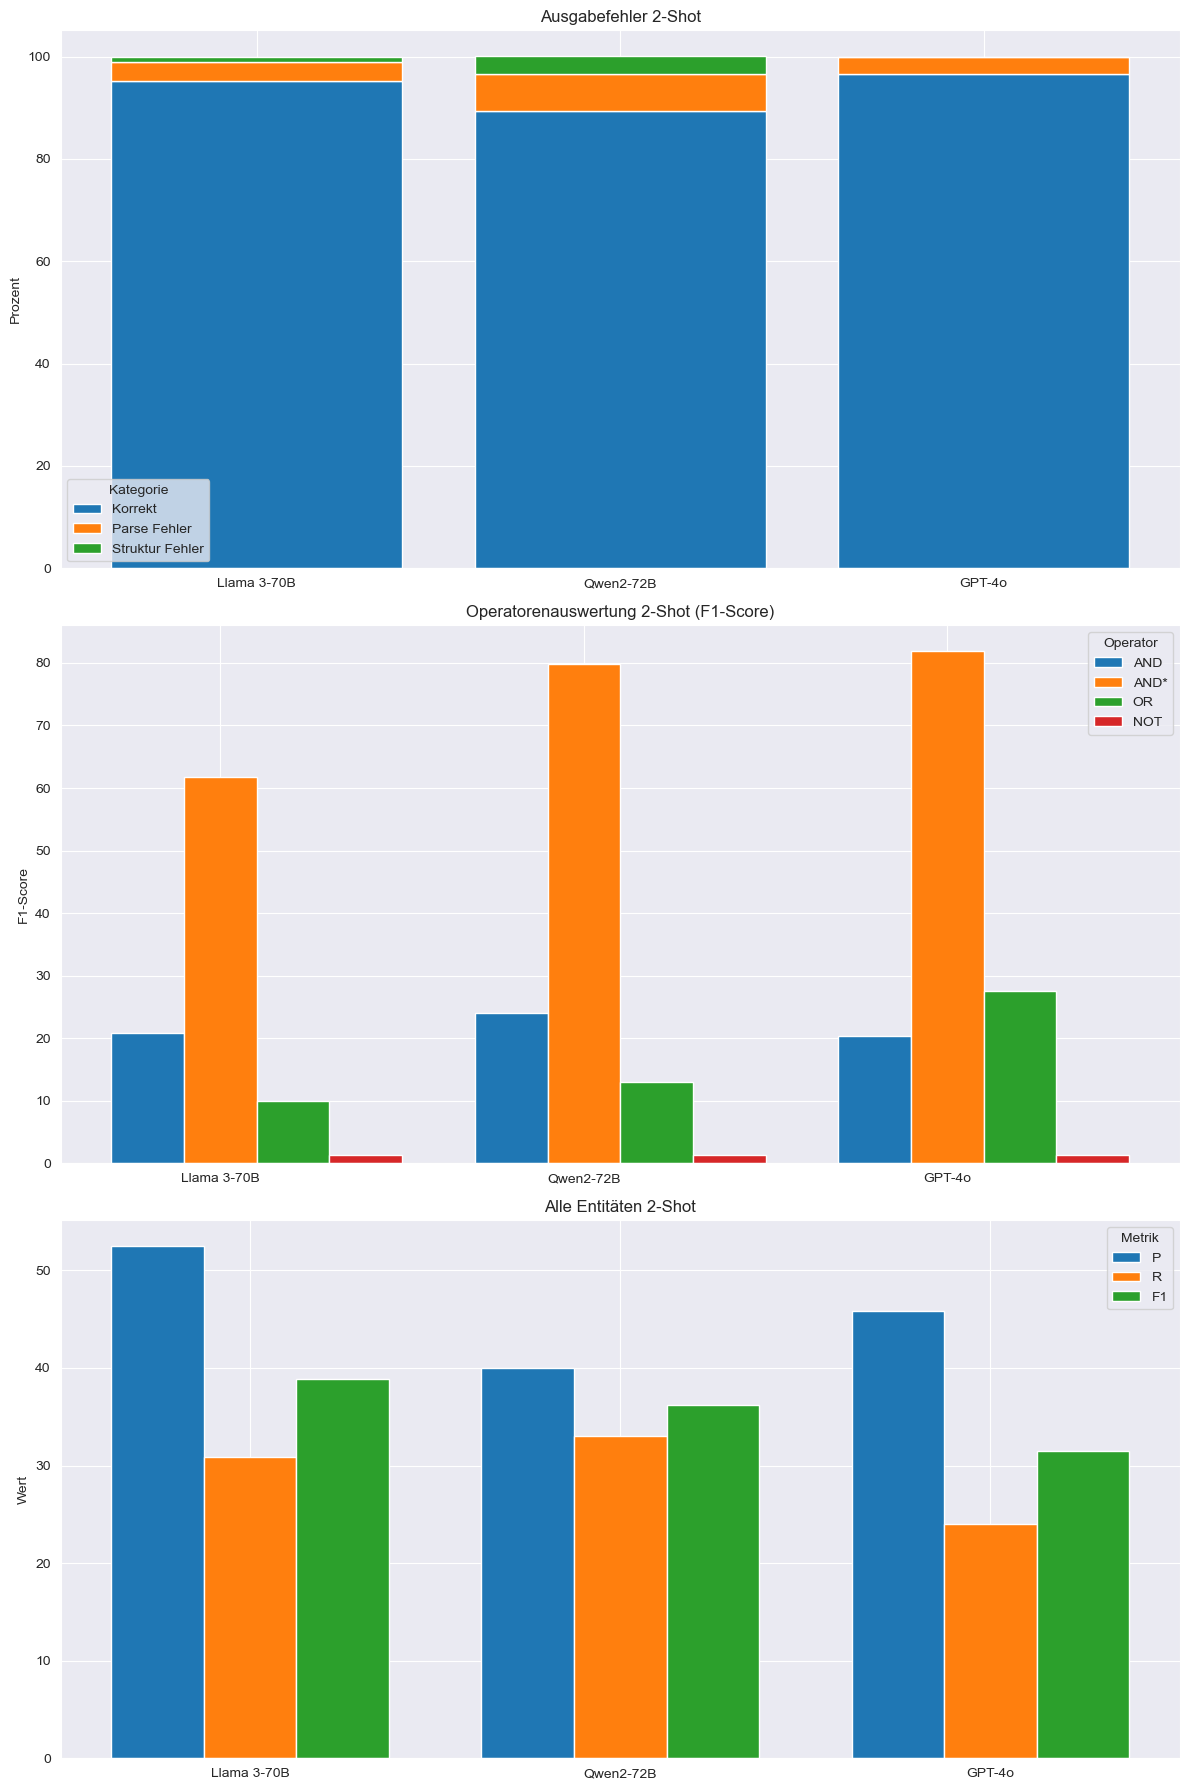

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Daten aus den Tabellen
models = ['Llama 3-70B', 'Qwen2-72B', 'GPT-4o']
output_errors = {
    'Korrekt': [95.3, 89.4, 96.5],
    'Parse Fehler': [3.7, 7.2, 3.5],
    'Struktur Fehler': [1.0, 3.5, 0.0]
}

operator_metrics = {
    'AND': [20.8, 24.1, 20.4],
    'AND*': [61.8, 79.8, 81.9],
    'OR': [10.0, 13.0, 27.5],
    'NOT': [1.3, 1.3, 1.3]
}

entity_metrics = {
    'P': [52.5, 40.0, 45.8],
    'R': [30.9, 33.0, 24.0],
    'F1': [38.9, 36.2, 31.5]
}

# Erstellen der Figur und Subplots
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 18))

# Plot 1: Ausgabefehler (gestapeltes Balkendiagramm)
bottom = np.zeros(3)
for category, values in output_errors.items():
    ax1.bar(models, values, bottom=bottom, label=category)
    bottom += values

ax1.set_title('Ausgabefehler 2-Shot')
ax1.set_ylabel('Prozent')
ax1.legend(title='Kategorie')

# Plot 2: Operatorenauswertung (Balkendiagramm)
x = np.arange(len(models))
width = 0.2
multiplier = 0

for operator, f1_scores in operator_metrics.items():
    offset = width * multiplier
    ax2.bar(x + offset, f1_scores, width, label=operator)
    multiplier += 1

ax2.set_title('Operatorenauswertung 2-Shot (F1-Score)')
ax2.set_xticks(x + width, models)
ax2.set_ylabel('F1-Score')
ax2.legend(title='Operator')

# Plot 3: Alle Entitäten (Balkendiagramm)
x = np.arange(len(models))
width = 0.25
multiplier = 0

for metric, values in entity_metrics.items():
    offset = width * multiplier
    ax3.bar(x + offset, values, width, label=metric)
    multiplier += 1

ax3.set_title('Alle Entitäten 2-Shot')
ax3.set_xticks(x + width, models)
ax3.set_ylabel('Wert')
ax3.legend(title='Metrik')

plt.tight_layout()
plt.show()

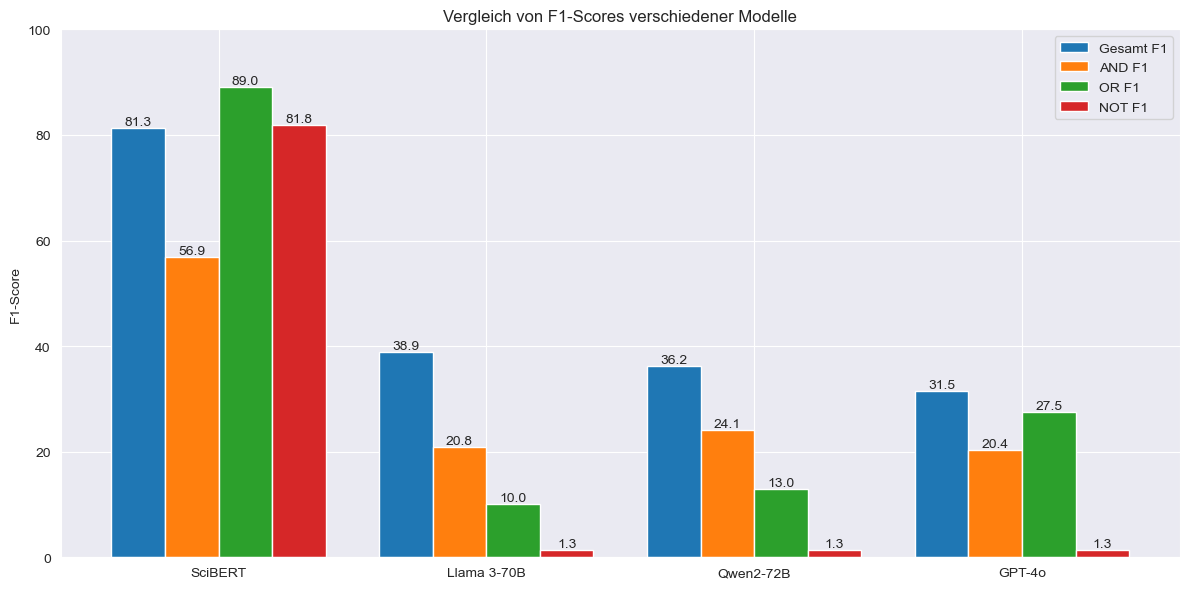

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Daten
models = ['SciBERT', 'Llama 3-70B', 'Qwen2-72B', 'GPT-4o']

# F1-Scores für verschiedene Metriken
f1_scores = {
    'Gesamt F1': [81.3, 38.9, 36.2, 31.5],
    'AND F1': [56.9, 20.8, 24.1, 20.4],
    'OR F1': [89.0, 10.0, 13.0, 27.5],
    'NOT F1': [81.8, 1.3, 1.3, 1.3]
}

# Plot erstellen
fig, ax = plt.subplots(figsize=(12, 6))

# Positionen für die Balken
x = np.arange(len(models))
width = 0.2
multiplier = 0

# F1-Scores plotten
for metric, scores in f1_scores.items():
    offset = width * multiplier
    ax.bar(x + offset, scores, width, label=metric)
    multiplier += 1

# Achsen und Titel konfigurieren
ax.set_ylabel('F1-Score')
ax.set_title('Vergleich von F1-Scores verschiedener Modelle')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(models)
ax.set_ylim(0, 100)

# Legende
ax.legend(loc='upper right')

# Werte über den Balken anzeigen
for i, metric in enumerate(f1_scores.keys()):
    for j, score in enumerate(f1_scores[metric]):
        ax.text(j + width*i, score, f'{score:.1f}', ha='center', va='bottom')

# Layout anpassen
plt.tight_layout()
plt.show()